# 06 — Conditional GANs (cGANs)

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a **conditional GAN**: a GAN whose generator is told *which class* to produce
- Understand how conditioning works: concatenate a label encoding to both G's and D's inputs
- Generate digits **by class**: ask the trained generator for a 0, a 1, ... a 9

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 05 "Building and Training a Simple GAN" — the same two networks, each given the class label as an extra input; the one-hot label encoding is the one from Course 01 (AIAT 111) — Unit 2, lesson 07.

**Used later in:** Course 10 — Unit 3, lesson 03, which applies the identical conditioning trick to a VAE.

---

## Introduction

The GAN from example 05 generates *some* digit — you cannot choose which. A **conditional GAN** (Mirza & Osindero, 2014) fixes that with one idea:

- **Generator**: input becomes `[z ⊕ one-hot(label)]` — G learns p(x | label)
- **Discriminator**: input becomes `[image ⊕ one-hot(label)]` — D judges "is this a real *seven*?", not just "is this real?"

D checking image–label *pairs* is what forces G to actually honor the label: producing a good digit of the wrong class gets punished.

---

## 🌍 Why this lesson exists — ControlNet, and the end of re-rolling the prompt

The one-line change in this notebook — put the condition into *both* networks — is the same change that made image generation usable as a tool rather than a slot machine. **ControlNet** (Zhang, Rao & Agrawala, ICCV 2023, arXiv 2302.05543) conditions Stable Diffusion on a pose skeleton, depth map or edge map, and is now the standard mechanism in the open Stable Diffusion ecosystem for "keep this exact pose / this exact layout". Before conditioning existed, an illustrator wanting a character in a specific pose re-rolled the prompt dozens of times and hoped; after it, the pose is an *input*.

**What goes wrong without this:** an unconditional generator cannot be asked for anything. If your requirement is "a 7", "a shirt in this fabric", "this building at night", you are reduced to sampling until you get lucky — and you have no way to guarantee that every class you need is even reachable.


## How the Code Differs From Example 05

Only three changes — find them in the code below:

1. `G` takes `LATENT_DIM + 10` inputs (noise ⊕ one-hot label)
2. `D` takes `784 + 10` inputs (image ⊕ one-hot label)
3. Every training step draws labels and feeds the *same* label to G and D

Everything else — the adversarial loop, losses, `.detach()` — is identical to example 05.

**Read this as a controlled experiment, because that is what it is.** The baseline is example 05: the same MNIST subset, the same adversarial loop, the same losses, the same `.detach()`. Exactly one thing changes here — the class label enters both G and D. Example 05's generator produced *some* digit and you could not say which; run this one and read the 10-row figure below. If the only change was the label and the only new behaviour is class control, then the label input is what produced it. That is the whole conclusion the figure supports — and note what it does **not** support: the samples are no sharper than example 05's.


Epoch 3/15 — D loss: 0.298  G loss: 3.818


Epoch 6/15 — D loss: 0.208  G loss: 4.587


Epoch 9/15 — D loss: 0.313  G loss: 2.846


Epoch 12/15 — D loss: 0.626  G loss: 1.934


Epoch 15/15 — D loss: 0.859  G loss: 1.534


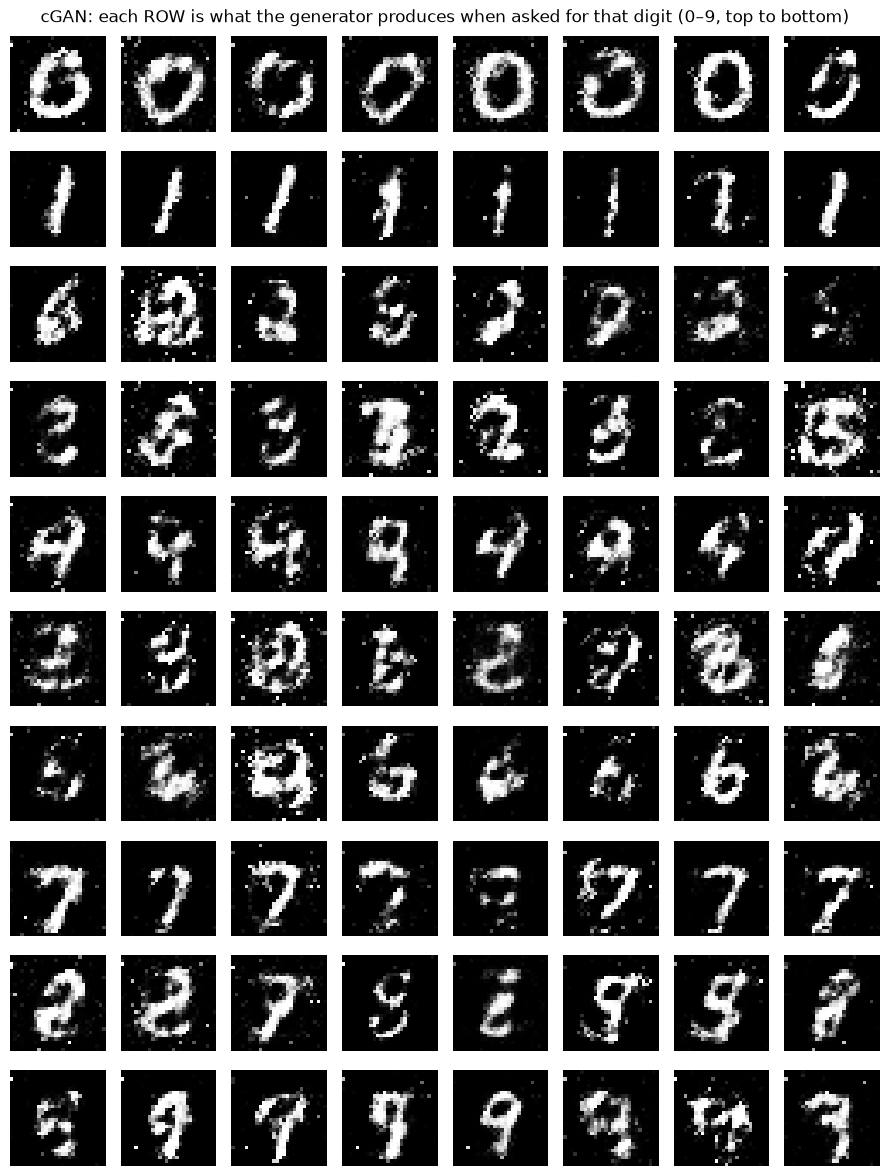

Row-by-row consistency = the label input controls generation.
(Samples are still rough after 15 CPU epochs — the point here is the control.)


In [1]:
# WHAT/WHY: train a conditional GAN on MNIST — same adversarial loop as
# example 05, but G and D both receive the class label, so afterwards we can
# REQUEST a specific digit. The final figure has one row per requested class.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128; N_CLASSES = 10

# ── Data in [-1, 1]; this time we KEEP the labels ─────────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: [noise ⊕ one-hot label] → image (change #1) ────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM + N_CLASSES, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),                    nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),                  nn.Tanh()
)
# ── Discriminator: [image ⊕ one-hot label] → real/fake (change #2) ────────
D = nn.Sequential(
    nn.Linear(28*28 + N_CLASSES, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),               nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),                 nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

def onehot(labels):
    # turn integer labels into one-hot vectors for concatenation
    return F.one_hot(labels, N_CLASSES).float()

EPOCHS = 15  # cGANs need a bit longer than example 05 for the label control to show
for epoch in range(EPOCHS):
    for real_imgs, labels in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        y = onehot(labels)                       # change #3: labels join every step
        # ── D step: real pairs → 1, fake pairs (same labels) → 0 ──────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(torch.cat([z, y], dim=1)).detach()
        loss_D = bce(D(torch.cat([real_flat, y], dim=1)), torch.ones(bs, 1)) + \
                 bce(D(torch.cat([fake,      y], dim=1)), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── G step: fool D with fresh fakes carrying the same labels ──────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(torch.cat([z, y], dim=1))
        loss_G = bce(D(torch.cat([fake, y], dim=1)), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Class-controlled generation: one row per REQUESTED digit 0..9 ─────────
G.eval()
n_per_class = 8
fig, axes = plt.subplots(N_CLASSES, n_per_class, figsize=(9, 12))
with torch.no_grad():
    for cls in range(N_CLASSES):
        z = torch.randn(n_per_class, LATENT_DIM)
        y = onehot(torch.full((n_per_class,), cls))   # ask for this class
        imgs = G(torch.cat([z, y], dim=1)).view(-1, 28, 28)
        for j in range(n_per_class):
            axes[cls, j].imshow(imgs[j], cmap='gray', vmin=-1, vmax=1)
            axes[cls, j].axis('off')
        axes[cls, 0].set_ylabel(str(cls))
plt.suptitle("cGAN: each ROW is what the generator produces when asked for that digit (0–9, top to bottom)")
plt.tight_layout(); plt.show()
print("Row-by-row consistency = the label input controls generation.")
print("(Samples are still rough after 15 CPU epochs — the point here is the control.)")


## 💬 Discuss

1. D judges image–label *pairs*, not images. Predict precisely what would go wrong if you conditioned G but left D unconditional — then say how you would spot that failure in the 10-row figure above.
2. Our samples are rough after 15 CPU epochs, but each row is unmistakably the requested digit: control arrived before fidelity. For a customer-facing design tool, which matters more? Does your answer change for a medical data-augmentation tool like the one in example 05?
3. One-hot conditioning gives ten choices. What breaks when a client needs ten thousand — "a shirt in *this* fabric", from a photograph? Name the change you would have to make to G's input.


## ⚠️ Where this breaks

**Conditioning guarantees nothing on its own.** G honours the label only because D can punish mismatched image–label pairs. Where a class is rare in the training data, D has seen few real pairs for it, so the punishment is weak and the guarantee degrades — precisely for the classes you most wanted control over.

**One-hot conditioning does not scale.** Past a few dozen discrete classes you need an embedding — text, pose, depth, a reference image — which is what ControlNet and every text-to-image system do. The concatenation trick is the idea; the one-hot vector is not.

**The label controls *which*, never *how good*.** Our rows show the correct digits and they are still blurry. No amount of conditioning improves sample quality; that is the job of architecture, data and training budget (examples 07–09).

**Verify, do not assume.** "The label is in the input" is not evidence the label is being honoured. Example 03 of Unit 3 measures it: a separate classifier checks what fraction of generated samples actually match the requested class. Build that check into any conditional generator you ship.


## 📚 References & Further Reading

**Papers:**
- Mirza & Osindero (2014) — [Conditional Generative Adversarial Nets](https://arxiv.org/abs/1411.1784) *(the cGAN idea used above)*
- Isola et al. (2017) — [Pix2Pix: Image-to-Image Translation](https://arxiv.org/abs/1611.07004) *(conditioning on entire images)*
- Zhu et al. (2017) — [CycleGAN](https://arxiv.org/abs/1703.10593) *(translation without paired data)*
- Zhang et al. (2023) — [Adding Conditional Control to Text-to-Image Diffusion Models (ControlNet)](https://arxiv.org/abs/2302.05543) *(today's standard way to condition image generators)*

**Applications:** medical image synthesis by pathology label, satellite-to-map conversion, sketch-to-photo tools


## 📝 Summary

You built a **conditional GAN** by making exactly three changes to example 05's unconditional GAN: label concatenated into G's input, into D's input, and into every training step. The result (see the 10-row figure) is **class-controlled generation** — each row shows the generator honoring a requested digit class. Conditioning on richer signals (full images in Pix2Pix, text embeddings in text-to-image systems) follows the same principle.
